# Using scMKL for Multimodal Cell Typing

To run tutorials, install plotnine and jupyter into your scMKL env with pip install plotnine jupyter. Here we will run scMKL on subsets of two multimodal PBMC data sets (scRNA and scATAC). We will use cells from the 10k PBMC data set to train on (646 cells), and test on cells from the 3k PBMC data set (316 cells). The data set cell type labels are comprised of B, CD14+ Monocytes, CD16+ Monocytes, CD4 T, CD8 T, Dendritic, and NK cells. The RNA assays contain 21,284 features while the ATAC assays contain 76,640 regions.

### Importing Modules
Data is read-in and saved using Numpy and AnnData.

In [1]:
import scmkl

import pickle
import numpy as np
import anndata as ad

/home/vangordi/miniconda3/envs/new_scmkl/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reading in Data
There are four pieces of data (per modality) required for scMKL:
- The data matrix itself with cells as rows and features as columns.
    - Can be either a Numpy array or SciPy sparse array (scipy.sparse.csc_array is the recommended format).  
- The sample labels in a Numpy array.
- Feature names in a Numpy array. These are the names of the features corresponding with the data matrix columns.
- A dictionary with grouping data.  The keys are the names of the groups, and the values are the corresponding features.
    - Example: {Group1: [feature1, feature2, feature3], Group2: [feature4, feature5, feature6], ...}.
    - See `getting_region_groupings.ipynb` and `getting_ATAC_groupings.ipynb` for more information on creating `group_dict`.

The data matrices, sample labels, and feature names can be pulled from AnnData objects.

In [2]:
# Reading in single-cell data by modality
rna_adata = ad.read_h5ad('data/pbmc_rna.h5ad')
atac_adata = ad.read_h5ad('data/pbmc_atac.h5ad')

# Reading in grouping dictionaries for each modality
rna_dict = np.load('data/_RNA_azimuth_pbmc_groupings.pkl', allow_pickle = True)
atac_dict = np.load('data/_ATAC_azimuth_pbmc_groupings.pkl', allow_pickle = True)

### Setting train test split
Here, we will train on only samples from the 10k PBMC data set and test on samples from the 3k PBMC data set.

In [3]:
train_test_split = np.array(['train'] * rna_adata.shape[0])
train_test_split[rna_adata.obs['batch'] == '3k'] = 'test'

### Creating an AnnData Object
scMKL takes advantage of AnnData's flexible structure to create a straight-forward approach to running scMKL. Using `scmkl.create_adata()` will create an AnnData object from input data that will include necessary variables for running scMKL. For more information, see scMKL's [documentation](https://ohsu-cedar-comp-hub.github.io/scMKL/).

In [4]:
rna_adata = scmkl.format_adata(rna_adata, cell_labels = 'celltypes', 
                               group_dict=rna_dict, scale_data=True, 
                               split_data=train_test_split, allow_multiclass=True)


atac_adata = scmkl.format_adata(atac_adata, cell_labels = 'celltypes', 
                                group_dict=atac_dict, scale_data=False, 
                                split_data=train_test_split, allow_multiclass=True)

### Running scMKL on multiclass data
Although scMKL is a binary classifier, we can create models for each cell class (ex. B cells versus all other cells) and use the output class probabilities to generate multiclass classifications.

`scmkl.one_v_rest()` creates models for each class and alpha value, then saves the results from each run as well as cell probabilities and multiclass predictions.

In [5]:
results = scmkl.one_v_rest(adatas = [rna_adata, atac_adata], names = ['rna', 'atac'], tfidf = [False, False],
                    alpha_list = np.array((0.05, 0.2, 0.35, 0.5, 0.65)), batch_size=64)

Estimating sigma and calculating Z for rna


/home/vangordi/miniconda3/envs/new_scmkl/lib/python3.12/site-packages/scmkl/one_v_rest.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
/home/vangordi/miniconda3/envs/new_scmkl/lib/python3.12/site-packages/scmkl/one_v_rest.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Estimating sigma and calculating Z for atac
Comparing B to other types
  Evaluating model. Alpha: 0.05
  Evaluating model. Alpha: 0.2
  Evaluating model. Alpha: 0.35
  Evaluating model. Alpha: 0.5
  Evaluating model. Alpha: 0.65
Comparing CD14+ Monocytes to other types
  Evaluating model. Alpha: 0.05
  Evaluating model. Alpha: 0.2
  Evaluating model. Alpha: 0.35
  Evaluating model. Alpha: 0.5
  Evaluating model. Alpha: 0.65
Comparing CD16+ Monocytes to other types
  Evaluating model. Alpha: 0.05
  Evaluating model. Alpha: 0.2
  Evaluating model. Alpha: 0.35
  Evaluating model. Alpha: 0.5
  Evaluating model. Alpha: 0.65
Comparing CD4 T to other types
  Evaluating model. Alpha: 0.05
  Evaluating model. Alpha: 0.2
  Evaluating model. Alpha: 0.35
  Evaluating model. Alpha: 0.5
  Evaluating model. Alpha: 0.65
Comparing CD8 T to other types
  Evaluating model. Alpha: 0.05
  Evaluating model. Alpha: 0.2
  Evaluating model. Alpha: 0.35
  Evaluating model. Alpha: 0.5
  Evaluating model. Alpha: 

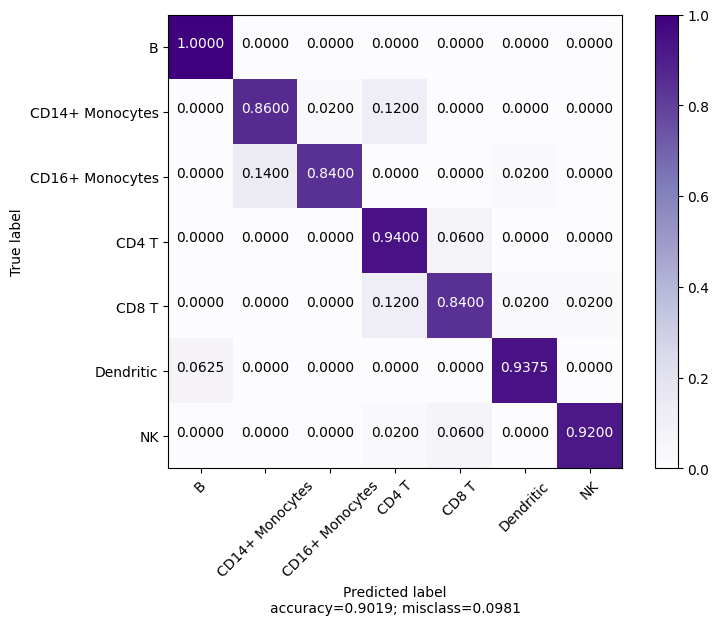

In [6]:
# Confusion matrix for smallest alpha
scmkl.plot_conf_mat(results, title = '', normalize = True)

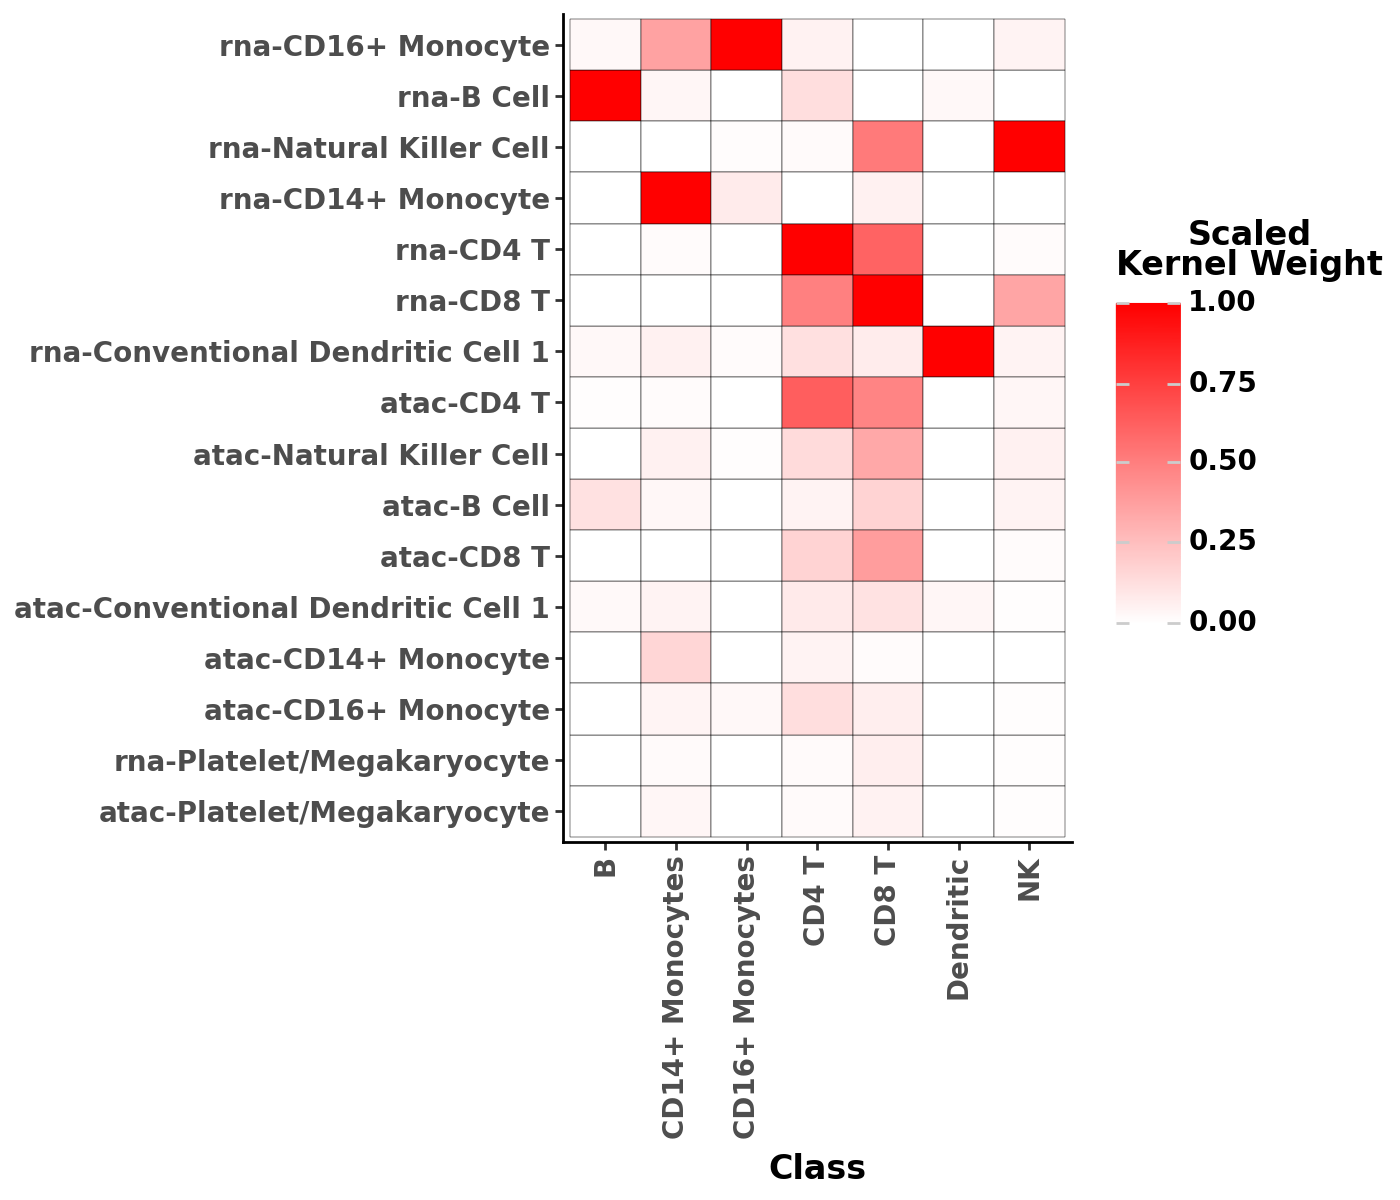

In [7]:
scmkl.weights_heatmap(results, scale_weights=True)

In [8]:
scmkl.get_summary(results)

,Alpha,AUROC,Number of Selected Groups,Top Group,Class
0,0.05,1.000000,7,rna-B Cell Markers,B
1,0.20,1.000000,2,rna-B Cell Markers,B
2,0.35,1.000000,2,rna-B Cell Markers,B
3,0.50,1.000000,2,rna-B Cell Markers,B
4,0.65,1.000000,1,rna-B Cell Markers,B
0,0.05,0.962030,13,rna-CD14+ Monocyte Markers,CD14+ Monocytes
1,0.20,0.921842,1,rna-CD14+ Monocyte Markers,CD14+ Monocytes
2,0.35,0.907707,1,rna-CD14+ Monocyte Markers,CD14+ Monocytes
3,0.50,0.905752,1,rna-CD14+ Monocyte Markers,CD14+ Monocytes
4,0.65,0.902519,1,rna-CD14+ Monocyte Markers,CD14+ Monocytes


In [9]:
with open('data/celltype_results.pkl', 'wb') as outfile:
    pickle.dump(results, outfile)